In [2]:
%%capture
try:
    import jaxtyping
except ImportError:
    !pip install jaxtyping

# First, import necessary libraries.
import matplotlib.pyplot as plt
import scipy.signal as signal
import torch
import torch.distributions as dist

from jaxtyping import Float, Int
from torch import Tensor

In [5]:
!wget -nc https://github.com/slinderman/ml4nd/raw/refs/heads/main/data/01_simple_spike_sorting/lab01_data.pt

--2026-08-15 09:34:55--  https://github.com/slinderman/ml4nd/raw/refs/heads/main/data/01_simple_spike_sorting/lab01_data.pt
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://media.githubusercontent.com/media/slinderman/ml4nd/refs/heads/main/data/01_simple_spike_sorting/lab01_data.pt [following]
--2026-08-15 09:34:56--  https://media.githubusercontent.com/media/slinderman/ml4nd/refs/heads/main/data/01_simple_spike_sorting/lab01_data.pt
Resolving media.githubusercontent.com (media.githubusercontent.com)... 2606:50c0:8002::154, 2606:50c0:8003::154, 2606:50c0:8001::154, ...
Connecting to media.githubusercontent.com (media.githubusercontent.com)|2606:50c0:8002::154|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 57666344 (55M) [application/octet-stream]
Saving to: ‘lab01_data.pt’

lab01_data.pt       100%[===================>]  5

In [6]:
# Load the data
data = torch.load("lab01_data.pt")
traces = data["traces"]
true_spike_times = data["true_spike_times"]
true_spike_ids = data["true_spike_ids"]
true_templates = data["true_templates"]

# Extract scalar constants 
SAMPLING_FREQUENCY = data["sampling_frequency"]
NUM_SAMPLES, NUM_CHANNELS = traces.shape
TRUE_NUM_SPIKES = true_spike_times.shape[0]
TRUE_NUM_NEURONS, WINDOW_SIZE, _ = true_templates.shape

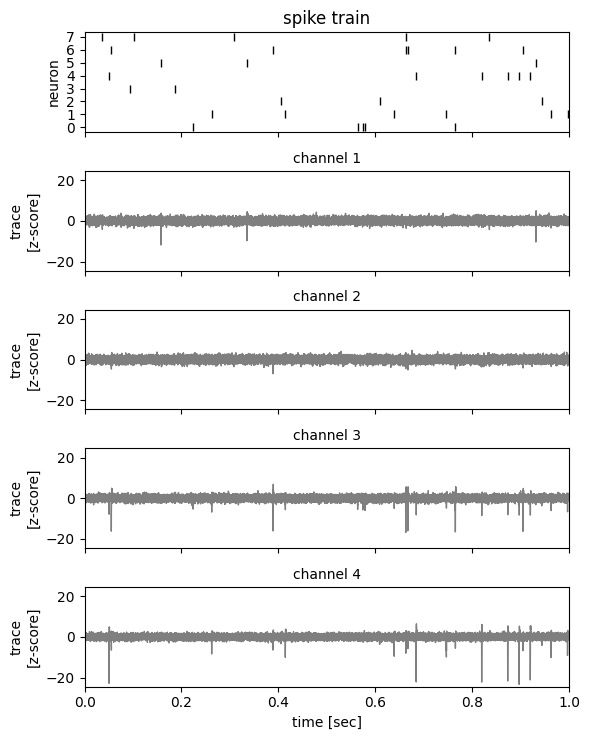

In [8]:
def plot_slice(traces: Float[Tensor, "num_samples num_channels"],
               spike_times: Int[Tensor, "num_spikes"],
               spike_ids: Int[Tensor, "num_spikes"],
               start_time: float=0,
               end_time: float=1.0,
               ylim: float=None):
    """
    Plot a slice of the recording and the corresponding spike times.

    Parameters
    ----------
    traces : torch.Tensor
        The voltage traces.
    spike_times : torch.Tensor
        The spike times, in samples.
    spike_ids : torch.Tensor
        The spike IDs, taking values 0,1,2,...,num_neurons-1
    start_time : float
        The start time of the slice, in seconds.
    end_time : float
        The end time of the slice, in seconds.
    ylim : float
        The y-limit for the traces. If None, it is set to 1.05 times the max absolute value of the traces.
    """
    # Extract constants
    num_samples, num_channels = traces.shape
    num_neurons = spike_ids.max() + 1

    # Extract the slice of the recording
    slc = slice(int(start_time * SAMPLING_FREQUENCY), int(end_time * SAMPLING_FREQUENCY))
    
    # Get the y-limit for traces if not specified
    if ylim is None:
        ylim = 1.05 * traces[slc].abs().max()

    # Make an array of times in seconds
    times_sec = torch.arange(0, num_samples) / SAMPLING_FREQUENCY
    spike_times_sec = times_sec[spike_times]
    spike_in_slice = (spike_times_sec >= start_time) & (spike_times_sec <= end_time)

    # Plot the spike raster
    fig, axs = plt.subplots(num_channels + 1, 1, sharex=True, figsize=(6, 1.5 * (num_channels + 1)))
    axs[0].plot(spike_times_sec[spike_in_slice], spike_ids[spike_in_slice], '|k', markersize=6)
    axs[0].set_ylabel("neuron")
    axs[0].set_yticks(torch.arange(0, num_neurons))
    axs[0].set_title("spike train")

    # Plot the voltage traces 
    for i in range(num_channels):
        axs[i+1].plot(times_sec[slc], traces[slc, i], color='k', lw=1, alpha=0.5)
        axs[i+1].set_title(f"channel {i+1}", fontsize=10)
        axs[i+1].set_ylim(-ylim, ylim)
        axs[i+1].set_ylabel("trace\n[z-score]")
        axs[i+1].set_xlim(start_time, end_time)
        if i == num_channels - 1: 
            axs[i+1].set_xlabel(f"time [sec]")
    
    plt.tight_layout()
    return fig, axs

def plot_waveforms(waveforms: Float[Tensor, "num_waveforms windows_size num_channels"],
                   name: str="waveform"):
    """
    Plot a grid of spike waveforms or templates.

    Parameters
    ----------
    waveforms : torch.Tensor
        The waveforms (or templates) to plot.

    name : str
        The name of the waveforms (or templates) to plot. Default is "waveform".
    """
    num_waveforms, window_size, num_channels = waveforms.shape
    times = torch.arange(-window_size//2, window_size//2) / SAMPLING_FREQUENCY * 1000
    fig, axs = plt.subplots(num_channels, num_waveforms, 
                            figsize=(1.25 * num_waveforms, 1.25 * num_channels), 
                            sharex=True, sharey=True)
    lim = 1.05 * waveforms.abs().max()
    for j in range(num_waveforms):
        for i in range(num_channels):
            axs[i,j].plot(times, waveforms[j,:,i], color='k', lw=1, alpha=0.5)
            axs[i,j].set_ylim(-lim, lim)
            # axs[i,j].set_xlabel("time [samples]")
            # axs[i,j].set_title(f"waveform {j}\n channel {i}")
            if j == 0:
                axs[i,j].set_ylabel(f"channel {i}\n [z-score]")
            if i == 0:
                axs[i,j].set_title(f"{name} {j}")
            if i == num_channels - 1:
                axs[i,j].set_xlabel(f"time [ms]")
    plt.tight_layout()
    
    return fig, axs

_ = plot_slice(
    traces,
    true_spike_times,
    true_spike_ids,
    start_time=0.0,
    end_time=1.0,
)

Text(0.5, 1.05, 'True templates')

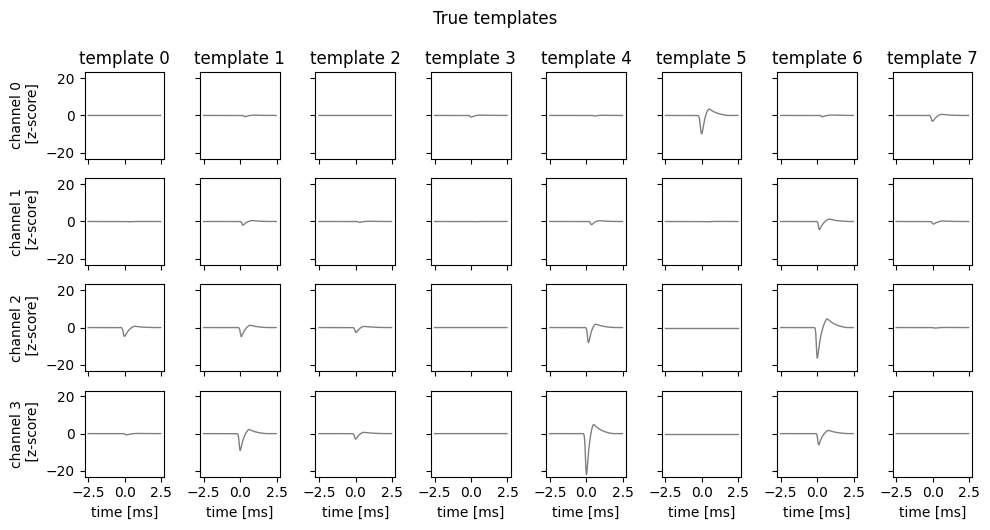

In [11]:
fig, axs = plot_waveforms(true_templates, name="template")
fig.suptitle("True templates", y=1.05)

In [ ]:
detected_spike_times = torch.where((traces<-4)==True)[0]
print(detected_spike_times)
print(detected_spike_times.shape)
# Make sure the result is a tensor
detected_spike_times = torch.tensor(detected_spike_times)
num_detected_spikes = detected_spike_times.shape[0]


tensor([   1097,    1515,    1516,  ..., 3599394, 3599395, 3599396])
torch.Size([21523])


/tmp/ipykernel_29919/1357594112.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  detected_spike_times = torch.tensor(detected_spike_times)


In [29]:
import scipy.signal as signal
import torch

# At each time point, take the most negative voltage across channels
min_trace = traces.min(dim=1).values

# Negate it so negative troughs become positive peaks
peak_signal = -min_trace

# Convert 3 ms into samples
min_distance = int(0.003 * SAMPLING_FREQUENCY)

# Find peaks that are at least 4 SD large
detected_spike_times, properties = signal.find_peaks(
    peak_signal.cpu().numpy(),
    height=4,
    distance=min_distance,
)

# Convert back to torch
detected_spike_times = torch.tensor(
    detected_spike_times,
    dtype=torch.long
)

num_detected_spikes = detected_spike_times.shape[0]
print(num_detected_spikes)

2132


In [30]:
print("raw threshold crossings:", (traces < -4).sum().item())

print(
    "unique threshold times:",
    torch.unique(torch.where(traces < -4)[0]).numel()
)

print("peak detections:", len(detected_spike_times))

raw threshold crossings: 21523
unique threshold times: 15941
peak detections: 2132
